Name: Shubhajeet Das <br />
Roll No.: 24AI10013 <br />
DL Lab Assignment 10-03-2026

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print(os.listdir())

cuda
['.idea', '.ipynb_checkpoints', '.venv', '.virtual_documents', '.vscode', '24AI10013', '24AI10013_DLDL', '24AI10013_Shubhajeet_03032026', '24AI10013_Shubhajeet_03032026.zip', '24AI10013_Shubhajeet_10022026', '24AI10013_Shubhajeet_13JAN2026', '24AI10013_Shubhajeet_20012026', 'anaconda_projects', 'cnn.py', 'data', 'demo.ipynb', 'demo_6.pdf', 'dl1.py', 'dl_lab_assgn.ipynb', 'kaggle_digit_recog', 'kaggle_dog', 'loading_models.ipynb', 'models', 'New folder', 'practice01.py', 'test.ipynb', 'test1.ipynb', 'unet_pp.py', 'Untitled14.ipynb', 'untitled14_1.ipynb']


In [2]:
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [3]:
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
SEED = 42

# Part 1 — Baseline Segmentation Model
In the demo notebook, you trained a simple encoder-decoder CNN for segmentation.

## Task 1 — Train the Baseline Model

Run the baseline segmentation model provided in the demo.
Record:
- Training loss
- Validation IoU
- Example predicted masks <br /> <br />
Questions
1. What kinds of errors do you observe in the predicted masks?
2. Are object boundaries predicted accurately?
3. Does the model struggle with thin structures (ears, tails, whiskers)?
Explain your observations briefly.

In [4]:
from torchvision.datasets import OxfordIIITPet
def process_mask(mask):
    mask = transforms.PILToTensor()(mask)
    mask = (mask == 1).float()
    return mask

image_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Lambda(process_mask)
])

dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

In [5]:
len(dataset)

3680

In [6]:
from torch.utils.data import DataLoader, SubsetRandomSampler
dataset_size = len(dataset)
split = int(0.8 * dataset_size)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
indices = torch.randperm(dataset_size).tolist()

train_indices, remaining_indices = indices[:split], indices[split:]
val_split = int(0.5 * len(remaining_indices))
val_indices, test_indices = remaining_indices[:val_split], remaining_indices[val_split:]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)
test_sampler = SubsetRandomSampler(test_indices)

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=val_sampler)
test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler)
print("Loaders created")

Loaders created


In [7]:
class SimpleSegNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32,16,2,stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,2,stride=2),
            nn.Sigmoid()
        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [7]:
import torch.nn.functional as F
from tqdm import tqdm

class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = inputs.view(inputs.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        inputs = torch.clamp(inputs, min=1e-7, max=1-1e-7)
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        intersection = (inputs * targets).sum(dim=1)                            
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum(dim=1) + targets.sum(dim=1) + smooth)  
        dice_loss = dice_loss.mean()
        return BCE + dice_loss

def iou_score(outputs, labels):
    smooth = 1e-6
    intersection = (outputs * labels).sum((1, 2, 3))
    union = (outputs + labels).gt(0).float().sum((1, 2, 3))
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

def train_model(model, train_loader, val_loader, optimizer=None, criterion=None, verbose=True):
    os.makedirs("./models", exist_ok=True)
    if criterion is None:
        criterion = DiceBCELoss()
    
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    n_total_steps = len(train_loader)
    train_losses, val_losses, train_ious, val_ious = [], [], [], []
    best_val_loss = float('inf')
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        running_iou = 0.0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        for i, (images, labels) in enumerate(pbar):
            images = images.to(device)
            labels = (labels.to(device) > 0.5).float()
            
            optimizer.zero_grad()
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            if total_norm < 1e-7:
                print(f"WARNING: Very small gradients! Norm: {total_norm}")
                
            with torch.no_grad():
                predicted_masks = (outputs > 0.5).float()
                running_iou += iou_score(predicted_masks, labels).item()
            if verbose and (i + 1) % 50 == 0:
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        train_loss = running_loss / len(train_loader)
        train_iou = running_iou / len(train_loader)
        
        model.eval()
        v_loss = 0.0
        v_iou = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = (labels.to(device) > 0.5).float()
                
                outputs = model(images)
                v_loss += criterion(outputs, labels).item()
                
                pred = (outputs > 0.5).float()
                v_iou += iou_score(pred, labels).item()
        
        val_loss = v_loss / len(val_loader)
        val_iou = v_iou / len(val_loader)
        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_ious.append(train_iou)
        val_ious.append(val_iou)
        
        print(f"Epoch [{epoch+1}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f"./models/best_model.pth")
            if verbose: print("--> Saved checkpoint")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend(); plt.title("Loss History")
    
    plt.subplot(1, 2, 2)
    plt.plot(train_ious, label="Train IoU")
    plt.plot(val_ious, label="Val IoU")
    plt.legend(); plt.title("IoU History")
    plt.show()

In [8]:
def evaluate_model(model, test_loader, criterion=None):
    if criterion is None:
        criterion = DiceBCELoss()
    model.eval()
    test_loss = 0.0
    test_iou = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = (labels.to(device) == 1).float()
            outputs = model(images)
            loss = criterion(outputs, labels)
            batch_size = labels.size(0)
            test_loss += loss.item() * batch_size
            test_iou += iou_score(outputs, labels).item() * batch_size
            
    test_loss /= len(test_loader.dataset)
    test_iou /= len(test_loader.dataset)
    print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}")
    return test_loss, test_iou

Epoch 1/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:18<00:00,  2.52it/s]


Epoch [1] Train Loss: 1.3088 | Val Loss: 1.2939 | Val IoU: 0.0000


Epoch 2/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:14<00:00,  3.13it/s]


Epoch [2] Train Loss: 1.2682 | Val Loss: 1.2251 | Val IoU: 0.0895


Epoch 3/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:14<00:00,  3.13it/s]


...

Epoch [28] Train Loss: 1.0750 | Val Loss: 1.0583 | Val IoU: 0.3763


Epoch 29/30: 100%|█████████████████████████████████████████████████████████████████████| 46/46 [00:15<00:00,  2.98it/s]


Epoch [29] Train Loss: 1.0653 | Val Loss: 1.0470 | Val IoU: 0.3958


Epoch 30/30: 100%|█████████████████████████████████████████████████████████████████████| 46/46 [00:15<00:00,  2.97it/s]


Epoch [30] Train Loss: 1.0591 | Val Loss: 1.0653 | Val IoU: 0.3225


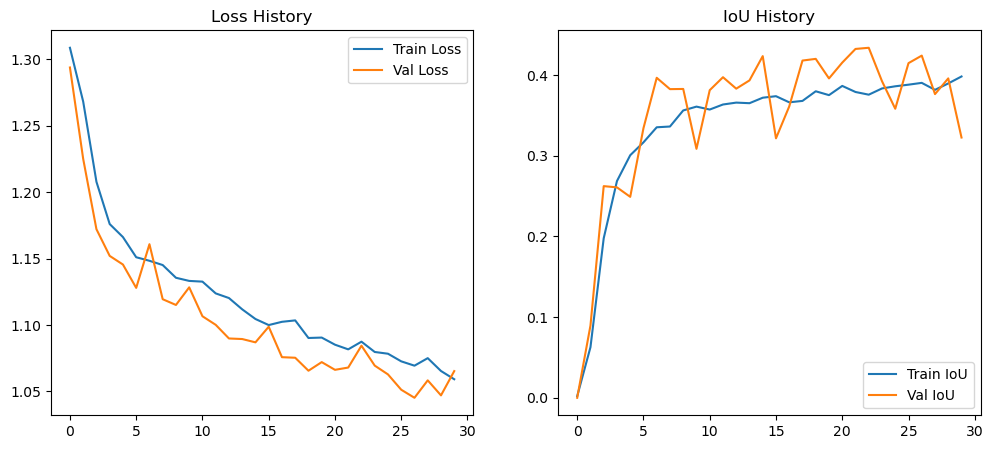

In [10]:
model = SimpleSegNet().to(device)
train_model(model, train_loader, val_loader, verbose=False)

In [11]:
evaluate_model(model, test_loader)

Test Loss: 0.1099, Test IoU: 0.0127


(0.10986359378565913, 0.012707473208074985)

In [9]:
def display_results(model, test_loader):
    model.eval()
    with torch.no_grad():
        images, raw_masks = next(iter(test_loader))
        images = images.to(device)
        masks = (raw_masks == 1).float()
        outputs = model(images)
        predicted_masks = (outputs > 0.5).float()
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))
    fig.suptitle('Example Predicted Masks vs. Ground Truth', fontsize=16)
    for i in range(4):
        axes[0, i].imshow(images[i].cpu().permute(1, 2, 0))
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')
        axes[1, i].imshow(raw_masks[i].cpu().squeeze(), cmap='gray')
        axes[1, i].set_title(f'Ground Truth {i+1}')
        axes[1, i].axis('off')
        axes[2, i].imshow(predicted_masks[i].cpu().squeeze(), cmap='gray')
        axes[2, i].set_title(f'Predicted {i+1}')
        axes[2, i].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

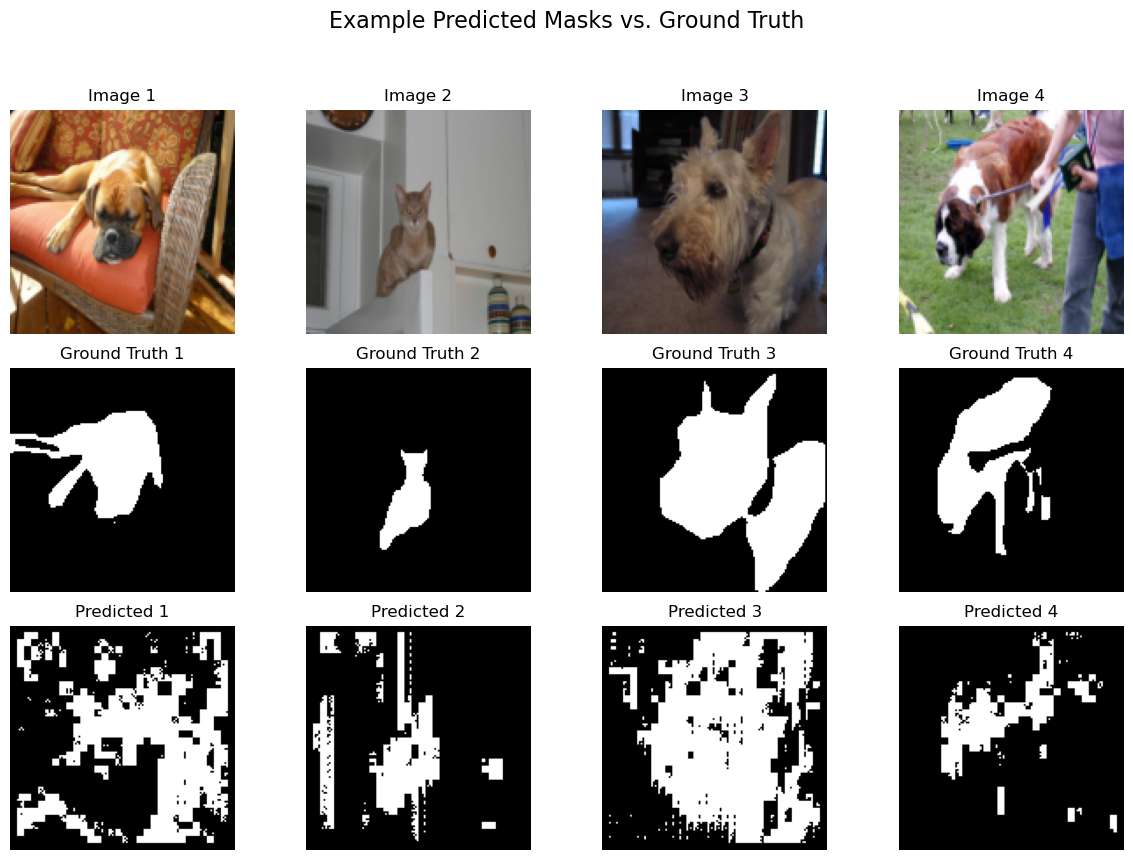

In [13]:
display_results(model, test_loader)

1. What kinds of errors do you observe in the predicted masks?

Too much background noise detected.

2. Are object boundaries predicted accurately?

Somewhat but with too much noise.

3. Does the model struggle with thin structures (ears, tails, whiskers)?

Yes, it struggles with that, often assuming a large noise because of it.

# Part 2 — Improving Segmentation with Skip Connections (U-Net)
## Task 2 — Implement a Mini U-Net
Modify the baseline network to include skip connections.

Architecture requirements:
- Encoder: at least 2 convolution blocks
- Decoder: at least 2 upsampling blocks
- Use ConvTranspose2d for upsampling
- Use torch.cat() for concatenating encoder features

Train the model using the same dataset.

Questions
1. Compare IoU between:
    - Baseline CNN
    - Mini U-Net
2. Do skip connections improve boundary predictions?
3. Why might combining low-level spatial features and high-level semantic features help segmentation?

## Ablation Study 1 — Model Depth
Modify your Mini U-Net:
- Add one additional encoder layer
- Add one additional decoder layer

Compare Model IoU:
- Mini U-Net (2 layers)
- Deeper Mini U-Net (3 layers)

Questions
1. Did increasing depth improve IoU?
2. Was there a noticeable increase in training time?
3. Did deeper models produce sharper masks?

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class MiniUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(128, 256)

        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = ConvBlock(256, 128) # 128 + 128 (skip)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)  # 64 + 64 (skip)

        self.final = nn.Conv2d(64, out_channels, 1)
        self.sigmoid = nn.Sigmoid()

        self._initialize_weights()

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        # Decoder
        d1 = self.up1(b)
        d1 = torch.cat([e2, d1], dim=1) # Skip connection 1
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([e1, d2], dim=1) # Skip connection 2
        d2 = self.dec2(d2)

        return self.sigmoid(self.final(d2))
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

class DeeperUNet(nn.Module):
    def __init__(self):
        super(DeeperUNet, self).__init__()
        # Encoder
        self.conv1 = ConvBlock(3, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = ConvBlock(32, 64)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(64, 128)

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec_conv1 = ConvBlock(128, 64) # 64 from bottleneck + 64 from skip

        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec_conv2 = ConvBlock(64, 32) # 32 from upconv + 32 from skip

        self.upconv3 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec_conv3 = ConvBlock(32, 16) # 16 from upconv + 16 from skip

        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        self._initialize_weights()

    def forward(self, x):
        # Encoder path
        enc1 = self.conv1(x)
        pool1 = self.pool1(enc1)

        enc2 = self.conv2(pool1)
        pool2 = self.pool2(enc2)

        enc3 = self.conv3(pool2)
        pool3 = self.pool3(enc3)

        # Bottleneck
        bottleneck = self.bottleneck(pool3)

        # Decoder path
        dec1 = self.upconv1(bottleneck)
        dec1 = torch.cat([dec1, enc3], dim=1) # Skip connection from enc3
        dec1 = self.dec_conv1(dec1)

        dec2 = self.upconv2(dec1)
        dec2 = torch.cat([dec2, enc2], dim=1) # Skip connection from enc2
        dec2 = self.dec_conv2(dec2)

        dec3 = self.upconv3(dec2)
        dec3 = torch.cat([dec3, enc1], dim=1) # Skip connection from enc1
        dec3 = self.dec_conv3(dec3)

        # Final layer
        output = self.final_conv(dec3)
        return self.sigmoid(output)
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

In [15]:
model_mini_unet = MiniUNet().to(device)

Epoch 1/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:36<00:00,  1.25it/s]


Epoch [1] Train Loss: 1.2213 | Val Loss: 1.2057 | Val IoU: 0.4054


Epoch 2/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:34<00:00,  1.32it/s]


Epoch [2] Train Loss: 0.9203 | Val Loss: 0.8719 | Val IoU: 0.5236


Epoch 3/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:34<00:00,  1.33it/s]


...

Epoch [28] Train Loss: 0.3217 | Val Loss: 0.4283 | Val IoU: 0.7322


Epoch 29/30: 100%|█████████████████████████████████████████████████████████████████████| 46/46 [00:34<00:00,  1.33it/s]


Epoch [29] Train Loss: 0.3164 | Val Loss: 0.4197 | Val IoU: 0.7411


Epoch 30/30: 100%|█████████████████████████████████████████████████████████████████████| 46/46 [00:35<00:00,  1.30it/s]


Epoch [30] Train Loss: 0.3152 | Val Loss: 0.4171 | Val IoU: 0.7426


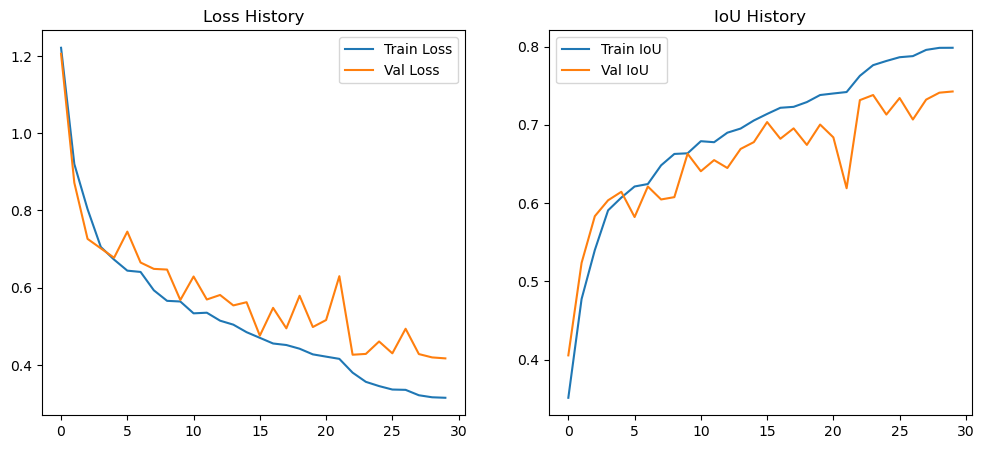

In [16]:
train_model(model_mini_unet, train_loader, val_loader, verbose=False)

In [17]:
evaluate_model(model_mini_unet, test_loader)

Test Loss: 0.0408, Test IoU: 0.0252


(0.04076517431632332, 0.02521990278492803)

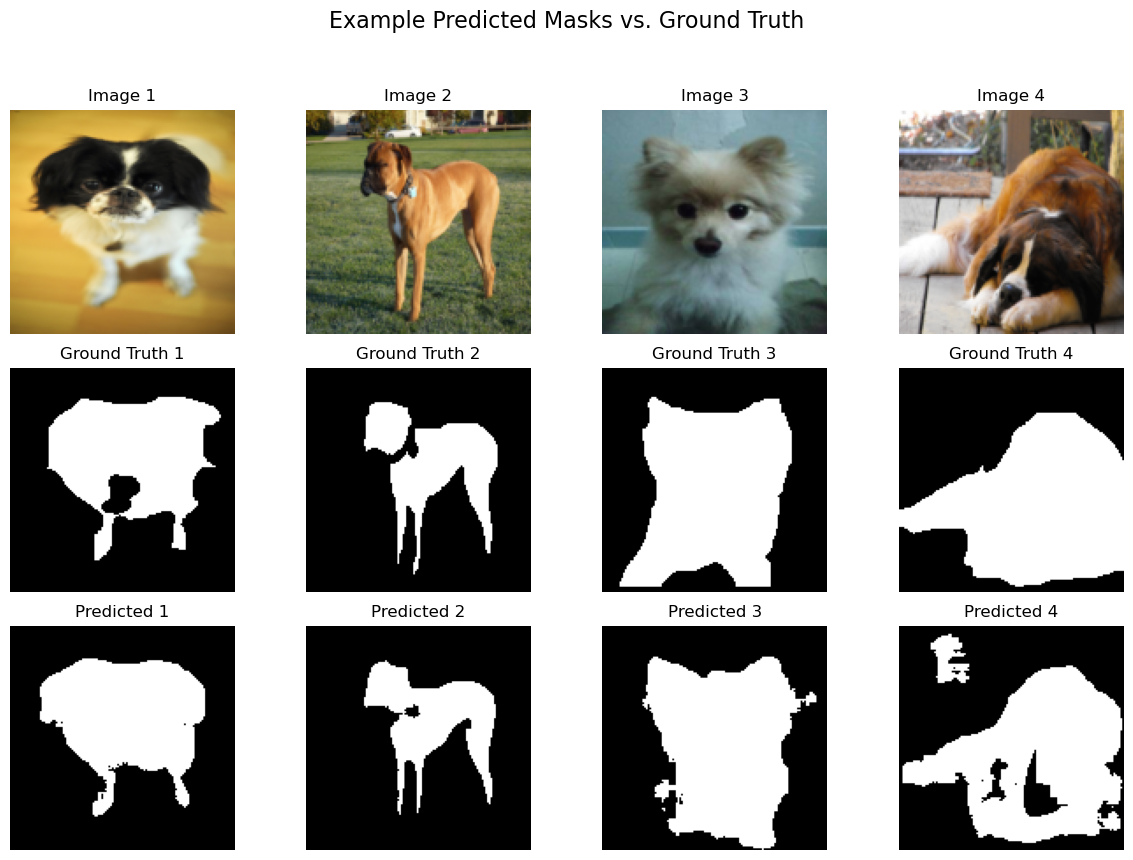

In [18]:
display_results(model_mini_unet, test_loader)

Epoch 1/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:21<00:00,  2.15it/s]


Epoch [1] Train Loss: 1.2148 | Val Loss: 1.0951 | Val IoU: 0.4774


Epoch 2/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:21<00:00,  2.15it/s]


Epoch [2] Train Loss: 0.8493 | Val Loss: 0.7998 | Val IoU: 0.5517


Epoch 3/30: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:21<00:00,  2.14it/s]


...

Epoch [28] Train Loss: 0.2439 | Val Loss: 0.4995 | Val IoU: 0.7150


Epoch 29/30: 100%|█████████████████████████████████████████████████████████████████████| 46/46 [00:20<00:00,  2.23it/s]


Epoch [29] Train Loss: 0.2229 | Val Loss: 0.5030 | Val IoU: 0.7095


Epoch 30/30: 100%|█████████████████████████████████████████████████████████████████████| 46/46 [00:20<00:00,  2.25it/s]


Epoch [30] Train Loss: 0.2162 | Val Loss: 0.5247 | Val IoU: 0.7102


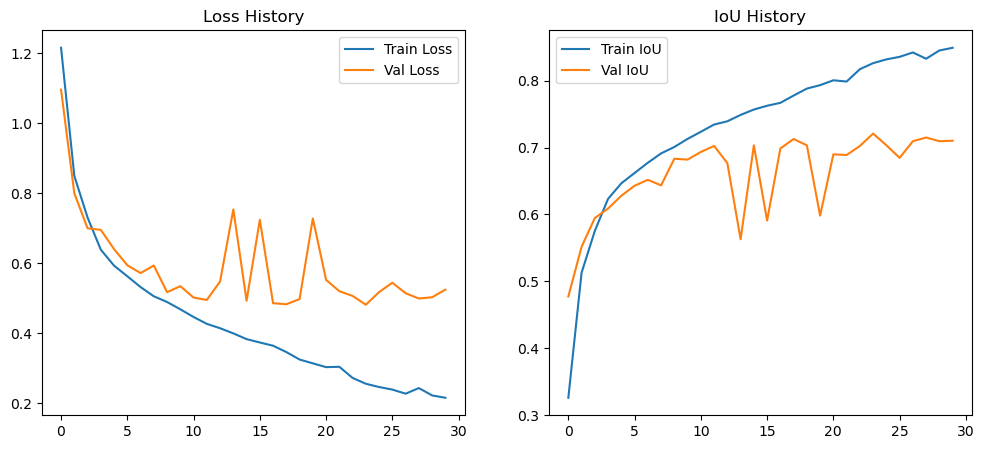

In [19]:
model_deeper_unet = DeeperUNet().to(device)
train_model(model_deeper_unet, train_loader, val_loader, verbose=False)

In [20]:
evaluate_model(model_deeper_unet, test_loader)

Test Loss: 0.0519, Test IoU: 0.0257


(0.05194953705953515, 0.02567896765211354)

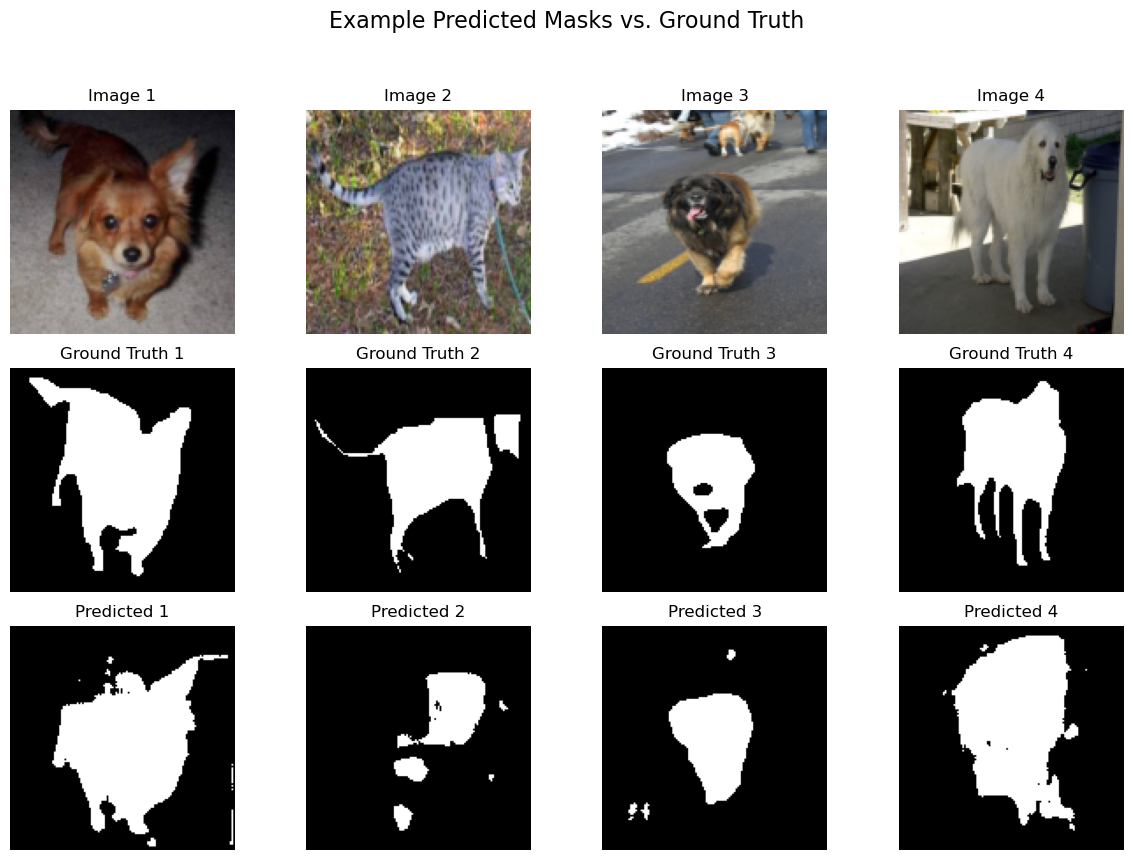

In [21]:
display_results(model_deeper_unet, test_loader)

| Model     | IoU |
|-----------| --- |
| Baseline  | 0.0127 |
| Mini-UNet | 0.0252 |
| Deeper-Mini-UNet | 0.0257 |

Results might differ slightly due to difference in shuffling.

2. Do skip connections improve boundary predictions?

Yes, very significantly. In a standard convolutional bottleneck (like the baseline), spatial information is lost during successive downsampling and pooling operations. By the time the signal reaches the deeper layers, the model has a high "semantic" understanding (knowing what is in the image) but has lost the fine-grained "spatial" precision (knowing exactly where the edges are). Skip connections resolve this by "triangulating" the features: they pass high-resolution feature maps from the contracting path directly to the expanding path. This allows the decoder to recover sharp object boundaries that would otherwise be blurred or lost in the bottleneck.

3. Why might combining low-level spatial features and high-level semantic features help segmentation?

- High-level Semantic Features: Provide global context and help the model identify that a group of pixels belongs to a specific class (e.g., "this is a car").

- Low-level Spatial Features: Contain rich information about gradients, edges, and textures. They are great at pinpointing boundaries but lack the context to know which object those edges belong to.

Combining them allows the model to leverage the best of both worlds. The high-level features guide the model to the correct object class, while the low-level features act as a refined template to "snap" the prediction mask onto the precise physical boundaries of that object.


1. Did increasing depth improve IoU?

Yes, but the improvement was marginal. The IoU increased from $0.0252$ to $0.0257$. While this represents a positive trend, the gain of only $0.0005$ suggests that the added complexity of the third layer did not provide a breakthrough in performance compared to the initial jump from the baseline.

2. Was there a noticeable increase in training time?

Yes. Adding an additional encoder and decoder layer increases the total number of trainable parameters and the computational overhead (FLOPs) for every forward and backward pass.

3. Did deeper models produce sharper masks?

Not significantly. In a U-Net architecture, the "sharpness" of object boundaries is primarily a function of the skip connections that bring high-resolution spatial details from the encoder to the decoder. Since both models utilize skip connections, the 3-layer version produces masks with similar edge definitions. The slight IoU increase suggests the deeper model is marginally better at "semantic" consistency (correctly identifying pixels) rather than fundamentally improving the spatial resolution of the edges.

# Part 3 — Understanding U-Net++
## Task 4 — Implement a Simplified U-Net++ Idea
Before concatenating the encoder feature with the decoder feature, pass the encoder feature through a refinement block:
Conv(3 * 3) → ReLU
Then concatenate.

Train this model with the same pipeline.

Questions Model IoU
- Baseline CNN
- Mini U-Net
- Mini U-Net++
1. Does feature refinement improve segmentation?
2. Why might refining encoder features help reduce the semantic gap?

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x): 
        return self.conv(x)

class UNetPlusPlusMini(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=32):
        super().__init__()
        nb = [base_channels, base_channels*2, base_channels*4]
        # Encoder
        self.enc0_0 = ConvBlock(in_channels, nb[0])
        self.enc1_0 = ConvBlock(nb[0], nb[1])
        self.enc2_0 = ConvBlock(nb[1], nb[2])
        self.pool = nn.MaxPool2d(2)
        
        # Decoder - simplified
        self.up2_0 = nn.ConvTranspose2d(nb[2], nb[1], 2, stride=2)
        self.conv1_1 = ConvBlock(nb[1] * 2, nb[1])
        
        self.up1_1 = nn.ConvTranspose2d(nb[1], nb[0], 2, stride=2)
        self.conv0_2 = ConvBlock(nb[0] * 2, nb[0])
        
        # Final layer
        self.final = nn.Conv2d(nb[0], out_channels, 1)
        self.sigmoid = nn.Sigmoid()
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
        nn.init.xavier_normal_(self.final.weight)
        if self.final.bias is not None:
            nn.init.constant_(self.final.bias, 0)
    
    def forward(self, x):
        x0_0 = self.enc0_0(x)
        x1_0 = self.enc1_0(self.pool(x0_0))
        x2_0 = self.enc2_0(self.pool(x1_0))
        
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up2_0(x2_0)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, self.up1_1(x1_1)], dim=1))
        
        return self.sigmoid(self.final(x0_2))

Epoch 1/30: 100%|██████████| 46/46 [00:13<00:00,  3.42it/s]


Epoch [1] Train Loss: 1.1425 | Val Loss: 1.0970 | Val IoU: 0.3559


Epoch 2/30: 100%|██████████| 46/46 [00:12<00:00,  3.78it/s]


Epoch [2] Train Loss: 0.9852 | Val Loss: 0.9327 | Val IoU: 0.4604


Epoch 3/30: 100%|██████████| 46/46 [00:12<00:00,  3.58it/s]


...

Epoch [28] Train Loss: 0.6740 | Val Loss: 0.6742 | Val IoU: 0.6005


Epoch 29/30: 100%|██████████| 46/46 [00:12<00:00,  3.70it/s]


Epoch [29] Train Loss: 0.6787 | Val Loss: 0.7005 | Val IoU: 0.5833


Epoch 30/30: 100%|██████████| 46/46 [00:12<00:00,  3.62it/s]


Epoch [30] Train Loss: 0.6785 | Val Loss: 0.7103 | Val IoU: 0.5930


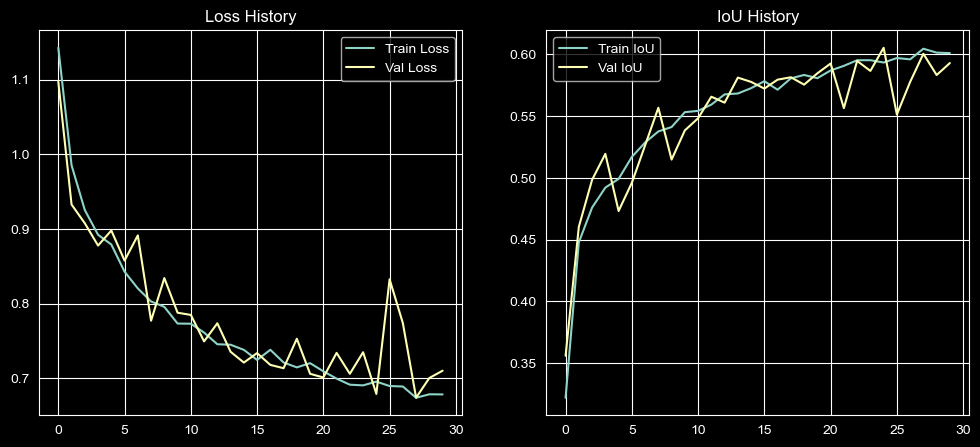

In [11]:
model_unetpp = UNetPlusPlusMini(base_channels=16).to(device)
train_model(model_unetpp, train_loader, val_loader, verbose=False)

In [12]:
evaluate_model(model_unetpp, test_loader)

Test Loss: 0.0703, Test IoU: 0.0231


(0.0703085852705914, 0.023137405644292418)

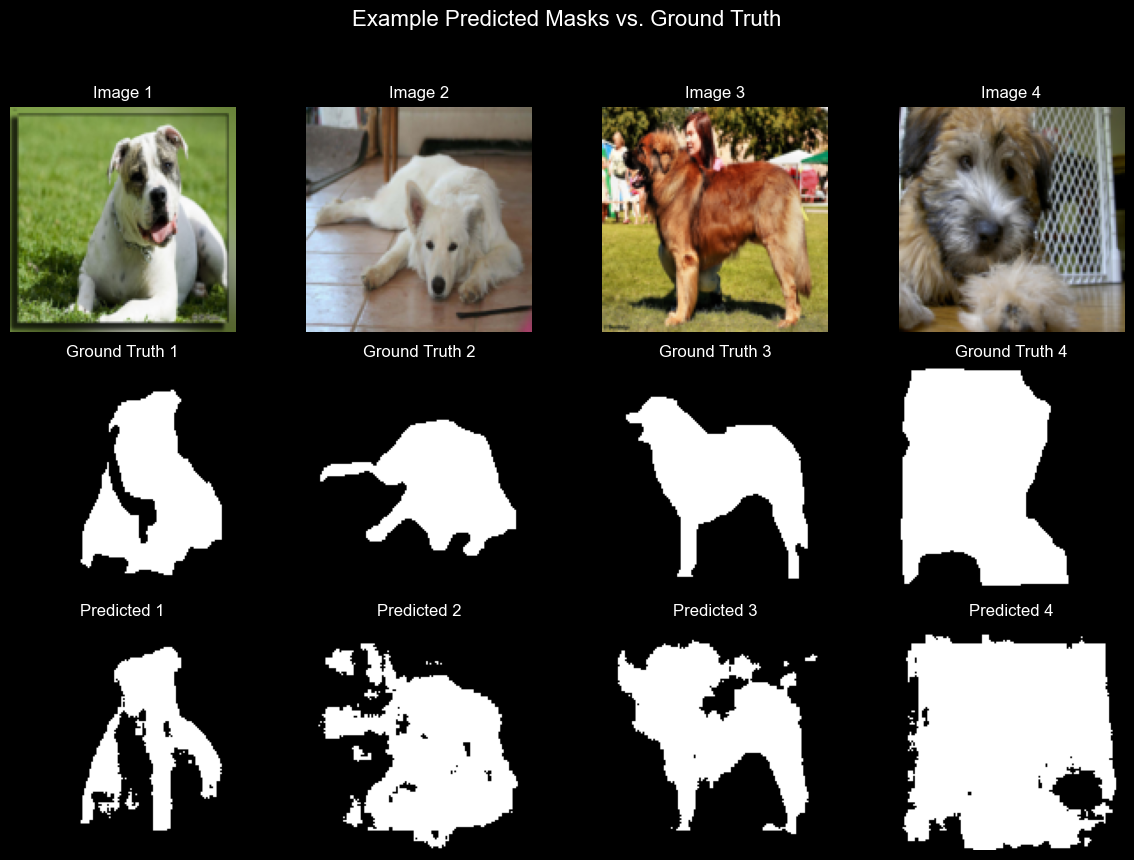

In [13]:
display_results(model_unetpp, test_loader)

| Model        | IoU |
|--------------| --- |
| Baseline CNN | 0.0127 |
| Mini-UNet    | 0.0252 |
| Mini-UNet++  | 0.0231 |

1. Does feature refinement improve segmentation?

Based on the provided results, no. The IoU actually decreased from 0.0252 (Mini-UNet) to 0.0231 (Mini-UNet++).
While feature refinement—often implemented through nested and dense skip pathways—is designed to capture more complex relationships, it also significantly increases the model's complexity. In this specific case, the drop in performance suggests that the added parameters may have led to overfitting or made the optimization landscape more difficult to navigate for the given dataset.


2. Why might refining encoder features help reduce the semantic gap?

Semantic gap might reduce because of these:
- Feature Alignment: It transforms the raw spatial data from the encoder into a format that is more "semantically compatible" with the decoder’s deep features. This ensures that when the two are concatenated, the model isn't trying to combine fundamentally different types of information.

- Gradient Flow: By using nested pathways, the model provides shorter paths for gradients to flow from the loss function back to the earlier layers. This allows the encoder to learn features that are more specifically tailored to the reconstruction task of the decoder, rather than just general feature extraction.

# Part 4 — Image Super-Resolution
# Part 5 — SRCNN
## Task 5 — Kernel Size Experiment
Train two versions:
Model A
$$9 \times 9 \rightarrow 5 \times 5 \rightarrow 5 \times 5$$
Model B
$$5 \times 5 \rightarrow 3 \times 3 \rightarrow 3 \times 3$$
Record training loss and validation PSNR.

Questions
1. Which configuration produced higher PSNR?
2. Why might larger kernels help capture image structures?

In [6]:
from torch.utils.data import Dataset, random_split
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.nn.functional as F

hr_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

pet_dataset = OxfordIIITPet(root="data", split="trainval", download=True, transform=hr_transform)

class PetSRDataset(Dataset):
    def __init__(self, base_ds, scale=2):
        self.ds = base_ds
        self.scale = scale
    
    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, idx):
        hr, _ = self.ds[idx]
        lr = F.interpolate(hr.unsqueeze(0), scale_factor=1/self.scale, mode="bicubic", align_corners=False)
        lr = F.interpolate(lr, size=hr.shape[1:], mode="bicubic", align_corners=False).squeeze(0)
        return lr, hr

torch.manual_seed(SEED)
n = len(pet_dataset)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val
train_hr, val_hr, test_hr = random_split(pet_dataset, [n_train, n_val, n_test])
train_loader_sr = DataLoader(PetSRDataset(train_hr), batch_size=BATCH_SIZE, shuffle=True)
val_loader_sr = DataLoader(PetSRDataset(val_hr), batch_size=BATCH_SIZE, shuffle=False)
test_loader_sr = DataLoader(PetSRDataset(test_hr), batch_size=BATCH_SIZE, shuffle=False)
print("SR pet loaders:", len(train_loader_sr.dataset), len(val_loader_sr.dataset), len(test_loader_sr.dataset))

SR pet loaders: 2944 368 368


In [7]:
NUM_EPOCHS = 10

In [21]:
class SrCNN_ModelA(nn.Module):
    """Model A: 9×9 → 5×5 → 5×5"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 3, kernel_size=5, padding=2)
        )

    def forward(self, x):
        return torch.clamp(self.net(x), 0, 1)


class SrCNN_ModelB(nn.Module):
    """Model B: 5×5 → 3×3 → 3×3"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return torch.clamp(self.net(x), 0, 1)

 10%|█         | 1/10 [00:18<02:47, 18.64s/it]

Epoch [1/10], Train loss 0.0203, Train PSNR 18.8125, Val loss 0.0053, Val PSNR 22.7486
Saved best model


 20%|██        | 2/10 [00:36<02:24, 18.02s/it]

Epoch [2/10], Train loss 0.0032, Train PSNR 25.0586, Val loss 0.0033, Val PSNR 24.8678
Saved best model


 30%|███       | 3/10 [00:53<02:03, 17.58s/it]

...

Epoch [8/10], Train loss 0.0013, Train PSNR 28.9967, Val loss 0.0011, Val PSNR 29.4167
Saved best model


 90%|█████████ | 9/10 [02:26<00:15, 15.53s/it]

Epoch [9/10], Train loss 0.0012, Train PSNR 29.1719, Val loss 0.0011, Val PSNR 29.4752
Saved best model


100%|██████████| 10/10 [02:41<00:00, 16.15s/it]

Epoch [10/10], Train loss 0.0011, Train PSNR 29.7001, Val loss 0.0011, Val PSNR 29.7061
Saved best model
Finished training


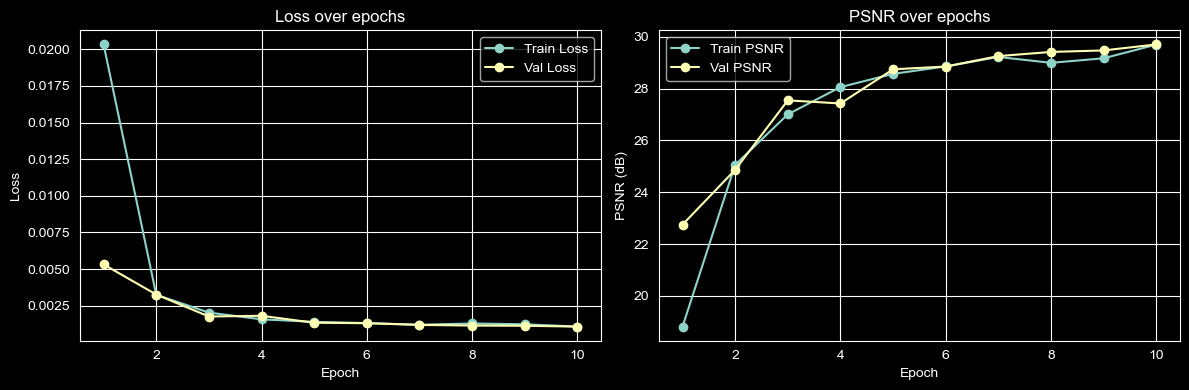

In [23]:
modelA = SrCNN_ModelA().to(device)
train_model(modelA, train_loader_sr, val_loader_sr, verbose=True)

 10%|█         | 1/10 [00:14<02:11, 14.61s/it]

Epoch [1/10], Train loss 0.0385, Train PSNR 17.1376, Val loss 0.0068, Val PSNR 21.7076
Saved best model


 20%|██        | 2/10 [00:28<01:53, 14.19s/it]

Epoch [2/10], Train loss 0.0042, Train PSNR 23.9203, Val loss 0.0028, Val PSNR 25.5602
Saved best model


 30%|███       | 3/10 [00:42<01:37, 13.93s/it]

...

Epoch [8/10], Train loss 0.0010, Train PSNR 29.8062, Val loss 0.0011, Val PSNR 29.7250
Saved best model


 90%|█████████ | 9/10 [02:03<00:13, 13.56s/it]

Epoch [9/10], Train loss 0.0010, Train PSNR 29.9375, Val loss 0.0010, Val PSNR 29.9201
Saved best model


100%|██████████| 10/10 [02:17<00:00, 13.77s/it]

Epoch [10/10], Train loss 0.0010, Train PSNR 29.9206, Val loss 0.0010, Val PSNR 30.0026
Saved best model
Finished training


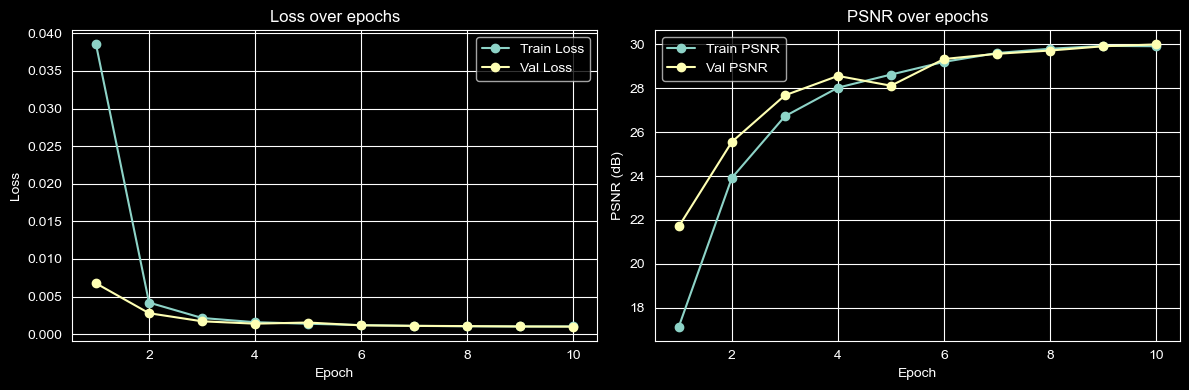

In [24]:
modelB = SrCNN_ModelB().to(device)
train_model(modelB, train_loader_sr, val_loader_sr, verbose=True)

| Kernel | PSNR |
| --- | --- |
| 9, 5, 5 | 29.7061 |
| 5, 3, 3 | 30.0026 |

Though results might differ due to different shuffling of the dataset. The difference in PSNR is very small. Larger kernels lead to higher **receptive field** that helps minimize the mean squared error that PSNR measures.

## Task 6 — Learning Rate Experiment
Train SRCNN with two learning rates:
$10^{-3}$ and $10^{-4}$

Learning Rate PSNR

In [8]:
class SrCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.ReLU(),
            nn.Conv2d(64, 32, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 3, 5, padding=2)
        )
    
    def forward(self, x):
        return torch.clamp(self.net(x), 0, 1)

In [11]:
os.makedirs("./models", exist_ok=True)
from tqdm import tqdm
def psnr(pred, target):
    mse = F.mse_loss(pred, target, reduction='mean')
    if mse == 0:
        return torch.tensor(float('inf'))
    return 20 * torch.log10(torch.tensor(1.0)) - 10 * torch.log10(mse)

def train_model(model, train_loader, val_loader, optimizer=None, criterion=None, verbose=True):
    if criterion is None:
        criterion = nn.MSELoss()
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    n_total_steps = len(train_loader)
    epochs = []
    train_losses = []
    val_losses = []
    train_psnrs = []
    val_psnrs = []
    best_val_loss = float('inf')
    
    for epoch in tqdm(range(NUM_EPOCHS)):
        train_loss = 0.
        val_loss = 0.
        train_psnr = 0.
        val_psnr = 0.
        
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            batch_size = labels.size(0)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            train_loss += loss.item() * batch_size
            train_psnr += psnr(outputs, labels).item() * batch_size
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if verbose and (i + 1) % 50 == 0:
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}")
        
        train_loss /= len(train_loader.dataset)
        train_psnr /= len(train_loader.dataset)
        epochs.append(epoch + 1)
        train_losses.append(train_loss)
        train_psnrs.append(train_psnr)
        
        model.eval()
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                batch_size = labels.size(0)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * batch_size
                val_psnr += psnr(outputs, labels).item() * batch_size
        
        val_loss /= len(val_loader.dataset)
        val_psnr /= len(val_loader.dataset)
        val_losses.append(val_loss)
        val_psnrs.append(val_psnr)
        
        if verbose:
            print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Train loss {train_loss:.4f}, Train PSNR {train_psnr:.4f}, Val loss {val_loss:.4f}, Val PSNR {val_psnr:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, f"./models/Epoch{epoch+1}.pth")
            if verbose:
                print("Saved best model")
    
    if verbose:
        print("Finished training")
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss", marker="o")
    plt.plot(epochs, val_losses, label="Val Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss over epochs")
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_psnrs, label="Train PSNR", marker="o")
    plt.plot(epochs, val_psnrs, label="Val PSNR", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("PSNR (dB)")
    plt.legend()
    plt.title("PSNR over epochs")
    
    plt.tight_layout()
    plt.show()

 10%|█         | 1/10 [00:16<02:29, 16.59s/it]

Epoch [1/10], Train loss 0.0230, Train PSNR 18.0430, Val loss 0.0071, Val PSNR 21.4892
Saved best model


 20%|██        | 2/10 [00:34<02:17, 17.13s/it]

Epoch [2/10], Train loss 0.0050, Train PSNR 23.0283, Val loss 0.0039, Val PSNR 24.1221
Saved best model


 30%|███       | 3/10 [00:51<01:59, 17.04s/it]

...

Epoch [8/10], Train loss 0.0013, Train PSNR 28.9848, Val loss 0.0013, Val PSNR 29.0108
Saved best model


 90%|█████████ | 9/10 [03:07<00:22, 22.03s/it]

Epoch [9/10], Train loss 0.0013, Train PSNR 28.9440, Val loss 0.0013, Val PSNR 28.9979


100%|██████████| 10/10 [03:28<00:00, 20.88s/it]

Epoch [10/10], Train loss 0.0012, Train PSNR 29.1160, Val loss 0.0012, Val PSNR 29.3108
Saved best model
Finished training


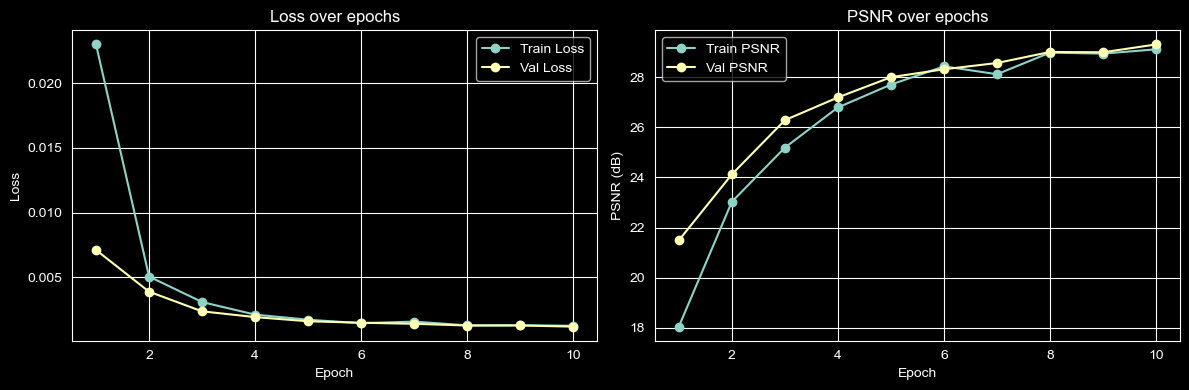

In [16]:
model_srcnn1 = SrCNN().to(device)
LEARNING_RATE = 1e-3
opt = torch.optim.Adam(model_srcnn1.parameters(), lr=LEARNING_RATE)
train_model(model_srcnn1, train_loader_sr, val_loader_sr, optimizer=opt, verbose=True)

 10%|█         | 1/10 [00:22<03:18, 22.05s/it]

Epoch [1/10], Train loss 0.0667, Train PSNR 13.7499, Val loss 0.0139, Val PSNR 18.5687
Saved best model


 20%|██        | 2/10 [00:44<02:56, 22.04s/it]

Epoch [2/10], Train loss 0.0100, Train PSNR 20.1468, Val loss 0.0061, Val PSNR 22.1656
Saved best model


 30%|███       | 3/10 [01:02<02:23, 20.55s/it]

...

Epoch [8/10], Train loss 0.0013, Train PSNR 28.8320, Val loss 0.0013, Val PSNR 28.8069
Saved best model


 90%|█████████ | 9/10 [03:14<00:22, 22.38s/it]

Epoch [9/10], Train loss 0.0013, Train PSNR 29.0150, Val loss 0.0013, Val PSNR 28.9773
Saved best model


100%|██████████| 10/10 [03:31<00:00, 21.11s/it]

Epoch [10/10], Train loss 0.0012, Train PSNR 29.1514, Val loss 0.0013, Val PSNR 28.9067
Finished training


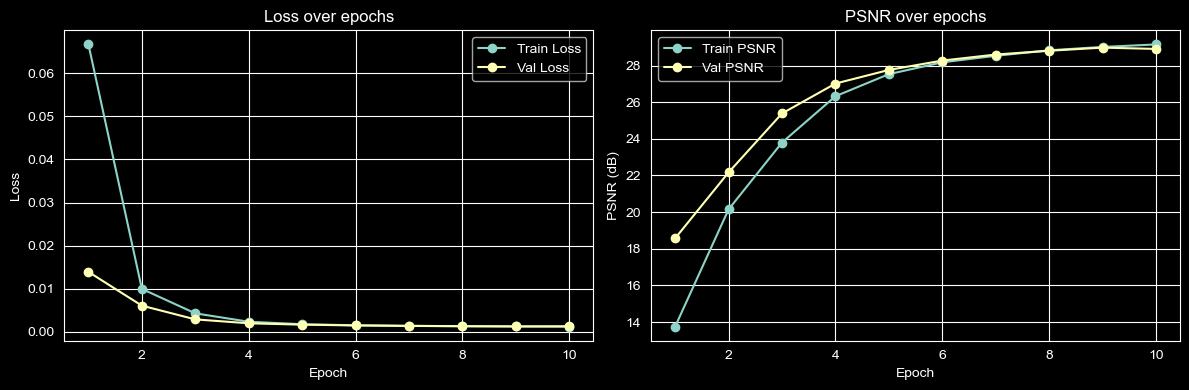

In [17]:
model_srcnn2 = SrCNN().to(device)
LEARNING_RATE = 1e-4
opt = torch.optim.Adam(model_srcnn2.parameters(), lr=LEARNING_RATE)
train_model(model_srcnn2, train_loader_sr, val_loader_sr, optimizer=opt, verbose=True)

Might different slightly due to different shuffling

| Learning Rate | PSNR |
| --- | --- |
| 1e-3 | 29.3108 |
| 1e-4 |  28.9067 |

Larger learning rate of 1e-3 is providing a slight advantage.

# Part 6 — Residual Learning
## Task 7 — Implement Residual Super-Resolution
Modify SRCNN so that:
```
residual = model(lr_img)
sr_image = lr_img + residual
```
Compute PSNR.

Questions
1. Compare PSNR between standard SRCNN and residual SRCNN.
2. Did the residual model converge faster?
3. Why is predicting only missing details easier?

 10%|█         | 1/10 [00:16<02:29, 16.60s/it]

Epoch [1/10], Train loss 0.0008, Train PSNR 30.9717, Val loss 0.0008, Val PSNR 30.8497
Saved best model


 20%|██        | 2/10 [00:33<02:12, 16.51s/it]

Epoch [2/10], Train loss 0.0008, Train PSNR 30.9909, Val loss 0.0008, Val PSNR 30.8497


 30%|███       | 3/10 [00:49<01:55, 16.45s/it]

...

Epoch [8/10], Train loss 0.0008, Train PSNR 30.9917, Val loss 0.0008, Val PSNR 30.8497


 90%|█████████ | 9/10 [02:30<00:16, 16.71s/it]

Epoch [9/10], Train loss 0.0008, Train PSNR 30.9866, Val loss 0.0008, Val PSNR 30.8497


100%|██████████| 10/10 [02:46<00:00, 16.69s/it]

Epoch [10/10], Train loss 0.0008, Train PSNR 30.9821, Val loss 0.0008, Val PSNR 30.8497
Finished training


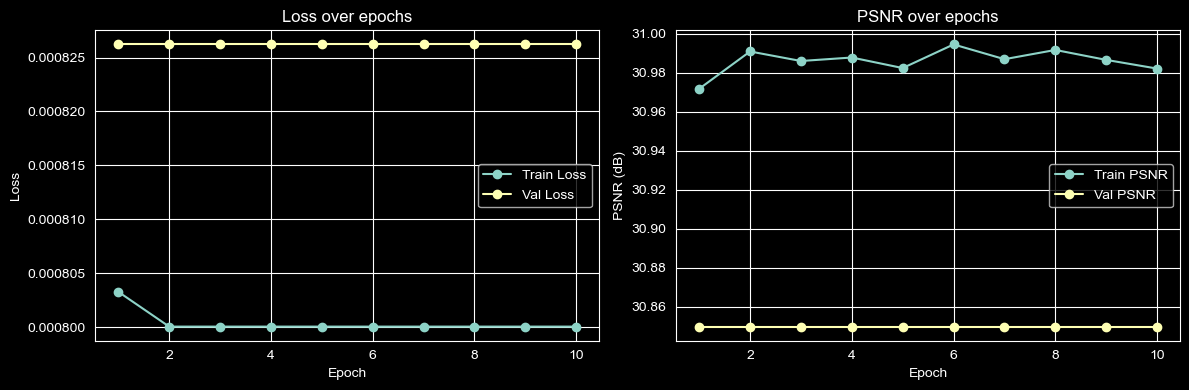

In [18]:
class ResidualSRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.srcnn = SrCNN()
    
    def forward(self, x):
        res = self.srcnn(x)
        return torch.clamp(x + res, 0, 1)

res_model = ResidualSRCNN().to(device)
LEARNING_RATE = 1e-3
opt_res = torch.optim.Adam(res_model.parameters(), lr=LEARNING_RATE)
train_model(res_model, train_loader_sr, val_loader_sr, optimizer=opt_res, criterion=nn.MSELoss(), verbose=True)

| Model | PSNR |
| --- | --- |
| Standard SRCNN | 29.3108 |
| Residual SRCNN | 30.8477 |

Residual SRCNN converge faster because of the following reasons:
- Learning residual mapping offers an easier optimization landscape
- Small numerical range leads to more stable gradients
- Gradients can flow directly through identity shortcut

Predicting only missing details is easier because the upsampled LR already contains ~90% of the information. The residual only needs to add high-frequency details (sharp edges, textures) which is a much more focused, constrained problem than reconstructing everything.

# Part 7 — Qualitative Comparison
Select three validation images and display:
- Bicubic upscaling
- SRCNN output
- Residual SRCNN output
- Ground truth HR image

Questions
1. Which textures are hardest to reconstruct?
2. Do models recover sharp edges or smooth regions better?
3. Does higher PSNR always correspond to better visual quality?

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07768736..0.8803574].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.109697446..1.1011478].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09070867..1.0648297].


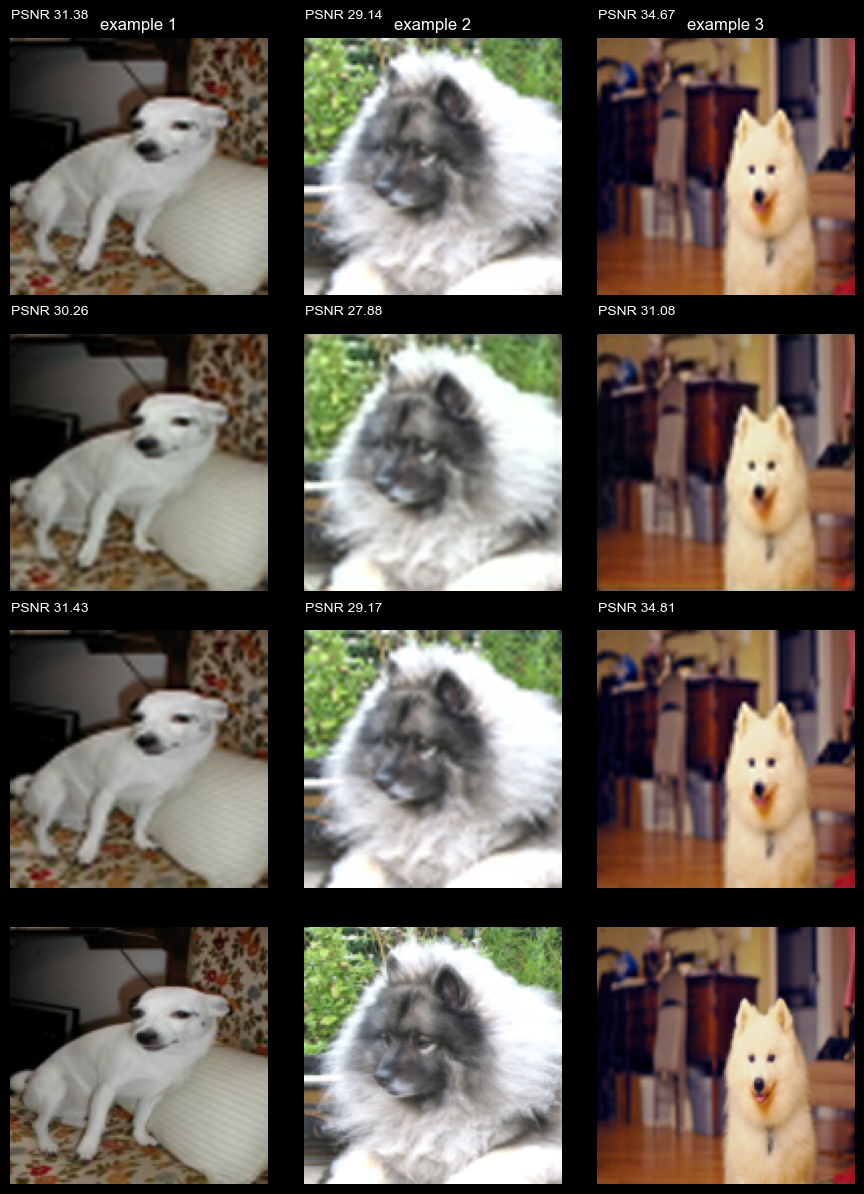

Top to Bottom -> Bicubic interpolated low res, SRCNN, ResSRCNN, Ground Truth high res


In [27]:
model_srcnn1.eval(); res_model.eval()
samples = []
with torch.no_grad():
    for lr_batch, hr_batch in test_loader_sr:
        samples.append((lr_batch[0], hr_batch[0]))
        if len(samples) >= 3:
            break

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(9, 12))
titles = ["Bicubic", "SRCNN", "Residual", "HR ground truth"]

for col, (lr, hr) in enumerate(samples):
    lr = lr.to(device); hr = hr.to(device)
    with torch.no_grad():
        out_src1 = model_srcnn1(lr.unsqueeze(0)).squeeze(0)
        out_res = res_model(lr.unsqueeze(0)).squeeze(0)
    bic = lr
    psnr_b = psnr(bic, hr).item()
    psnr_s1 = psnr(out_src1, hr).item()
    psnr_r = psnr(out_res, hr).item()

    for row, img in enumerate([bic, out_src1, out_res, hr]):
        axes[row, col].imshow(img.cpu().permute(1,2,0))
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"example {col+1}")
    axes[0, col].text(0, -10, f"PSNR {psnr_b:.2f}", color="white", backgroundcolor="black")
    axes[1, col].text(0, -10, f"PSNR {psnr_s1:.2f}", color="white", backgroundcolor="black")
    axes[2, col].text(0, -10, f"PSNR {psnr_r:.2f}", color="white", backgroundcolor="black")

for row, t in enumerate(titles):
    axes[row,0].set_ylabel(t, fontsize=12, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()
print("Top to Bottom -> Bicubic interpolated low res, SRCNN, ResSRCNN, Ground Truth high res")

1. Which textures are hardest to reconstruct?

    a) Fine, irregular textures like Grass, hair, fabric weave, tree foliage due to high-frequency, non-repeating patterns with no clear structure.

    b) Repetitive high-frequency patterns like Brick walls, window grilles, text, checkerboards due to aliasing during downsampling creates ambiguity.

    c) Thin structures like Power lines, fence wires, fine lines as they may disappear completely in low-res version.

2. Do models recover sharp edges or smooth regions better?

Yes Smooth regions are recovered MUCH better as MSE-trained models produce smooth, blurry results with high PSNR but poor edge quality.

3. Does higher PSNR always correspond to better visual quality?

No. Sometimes the best looking pictures have PSNR 1-2dB lower. This is because PSNR measures pixel-wise MSE while human perception cares about perceptual similarity (edges, textures, naturalness).